# The “Memory” of LLMs: Taking RoPE Extrapolation as an Entry Point

When discussing the “memory” of large language models, people usually distinguish among three kinds of memory: **parametric memory** stored in the model parameters, **contextual memory** supported by attention, and **external memory** represented by RAG, databases, and tool use. Correspondingly, people often evaluate long-context ability with tasks such as LongBench, RULER, and Needle-in-a-Haystack.

However, these evaluations are mostly conducted from the perspective of a human using a tool: Can the model answer questions? Can it find evidence? Can it complete long-document tasks? They measure usefulness at the behavioral level, rather than what kind of contextual ability a Transformer actually has at the mechanistic level.

From a lower-level mechanistic perspective, the question is no longer how many words a Transformer can “remember,” but rather:

> How can an attention network with finite depth, finite width, and positional encoding preserve, route, combine, and use information in the context as sequence length increases?

Note: “routing” here is not a strict mathematical term from the original Transformer paper. It is a descriptive term often used in recent analyses of Transformer mechanisms. It refers to how information from a token in the input passes through attention, residual connections, MLPs, and multi-layer representation transformations, and eventually affects the output. In other words, routing asks which path information takes inside the network.

### Decomposing contextual ability at different levels

From this perspective, the contextual ability of a Transformer can be decomposed into at least the following levels.

First, **attention reachability**. Can information from a token be accessed by later tokens? The core object here is the attention matrix. Metrics such as attention entropy, attention mass, and attention distance distribution can be used to observe whether the model actually builds effective connections between distant positions.

Second, **information retention**. After earlier information passes through multiple layers of transformations, how much of it remains in the hidden states? This can be analyzed through mutual information, linear probing, representation similarity, and related methods. If distant information is still formally inside the context window but is no longer recoverable in representation space, then the model has in effect “forgotten” it.

Third, **positional extrapolation ability**. Can the model really handle contexts longer than the training length? This involves properties of positional encoding mechanisms such as RoPE, ALiBi, and position interpolation. For RoPE, the key question is not how well the model scores on a long-document QA benchmark, but what happens to rotary phases, attention distributions, and representation structure when relative distances exceed the training window.

Fourth, **signal-to-noise ratio**. In a long context, is the information of the target token diluted by a large number of irrelevant tokens? As context length $n$ increases, the number of competing terms in softmax normalization also increases. Even if the target information still exists, its effective weight in the attention distribution may decrease.

Fifth, **compositional complexity**. Can the model implement multi-step information transfer across multiple attention layers? A single attention layer is more like one global read operation, whereas multiple attention layers can form path combinations across tokens and layers. Long-context ability depends not only on whether the model can read distant information, but also on whether it can combine scattered information into new representations.

Sixth, **effective context length**. This differs from the model's nominal context window. The truly effective context length should mean the maximum distance at which a distant information source still has a measurable effect on the output distribution. If removing a distant token barely changes the output distribution, then that token is inside the window but is not actually being used.

The strong performance of Transformers easily creates the impression that as long as all information is placed into the input, attention will automatically collect and use it, thereby achieving full memory. But this is more a behavioral-level intuition than a mechanistic fact. In practice, even when a rule is repeatedly emphasized in the prompt, the model may still violate it during later generation. However, this is not necessarily just a problem of “poor memory,” and it should not be understood through the psychological analogy of training subordinates or reminding humans.

Among these factors, positional encoding is especially important. Attention itself only computes correlations between token representations, whereas information retrieval in long contexts first requires the model to correctly judge the relative positional relationship between tokens. If positional relationships become distorted after length increases, distant tokens may still be inside the window, yet fail to participate in attention computation in the way the model learned during training. In other words, “being able to remember” first requires the model to maintain a stable positional geometry on longer sequences.

Therefore, this note will **take RoPE as an entry point and examine what happens when a language model trained on fixed-length token blocks encounters contexts longer than its training window**. The main topics include visualizing the numerical extrapolation behavior of RoPE, changes in attention under long-distance positional relationships, and analysis of how strongly contextual token information is retained. Through this, we try to reinterpret the so-called “memory” of large language models from a mechanistic perspective.

In summary, long-context ability can be divided into three levels:

**Behavioral-level metrics**: LongBench, RULER, Needle-in-a-Haystack.

**Mechanistic-level metrics**: attention entropy, attention distance, representation retention, causal ablation, and information flow.

**Mathematical-level questions**: complexity, capacity, positional extrapolation, softmax dilution, depth, and compositional paths.

This note is not concerned with whether a model is “easy to use” on long-context tasks. Instead, it asks how a Transformer preserves, transfers, and uses information under length extrapolation.


## The Principle and Implementation of RoPE

Common positional encoding methods include absolute positional encoding, relative positional encoding, ALiBi, and Rotary Position Embedding (RoPE), which is used by most current large language models.

Compared with traditional positional encodings, the most distinctive feature of RoPE is that it does not directly encode absolute positions. Instead, it uses rotation transformations so that the computation of attention naturally depends on the relative distance between tokens. This property gives RoPE better generalization ability in long-context tasks and also makes it an important entry point for studying Transformer contextual ability and length extrapolation.

Therefore, when discussing the “memory” of large language models, we first need to understand how RoPE works, why it can support long contexts, and why it gradually fails after exceeding the training length.


### The Mathematical Principle of RoPE

The core idea of RoPE can be summarized in one sentence:

> **By applying position-dependent rotations to Query and Key, RoPE makes the inner product used by attention depend only on the relative position between tokens, rather than on their absolute positions.**

Unlike traditional positional encodings that directly add position vectors to embeddings, RoPE incorporates positional encoding into the computation process of attention.


#### The objects RoPE operates on

Suppose the input sequence length is $L$ and the model hidden dimension is $d_{\mathrm{model}}$. After embedding and several preceding Transformer layers, the input representation of the current layer is

$$
X \in \mathbb{R}^{L \times d_{\mathrm{model}}}.
$$

For one attention head, Query and Key are obtained by linear projections:

$$
Q = XW_Q,
\qquad
K = XW_K.
$$

where

$$
W_Q,W_K \in \mathbb{R}^{d_{\mathrm{model}} \times d},
$$

and $d$ is the dimension of each attention head. Therefore,

$$
Q,K \in \mathbb{R}^{L \times d}.
$$

At this point, the **$m$-th row** of $Q$ denotes the Query vector corresponding to the $m$-th token:

$$
q_m = Q[m,:] \in \mathbb{R}^{d}.
$$

The **$n$-th row** of $K$ denotes the Key vector corresponding to the $n$-th token:

$$
k_n = K[n,:] \in \mathbb{R}^{d}.
$$

In other words, $q_m$ is not an independent Query matrix. It is the row vector in the whole Query matrix $Q$ corresponding to the $m$-th position. Similarly, $k_n$ is the row vector in the Key matrix $K$ corresponding to the $n$-th position. Here, $d$ refers to the feature dimension inside each attention head. We assume by default that the head dimension $d$ is even. If $d$ is odd, RoPE can only be applied to the even number of dimensions, with the remaining dimension left unchanged, or the model can simply be designed with an even head dimension.


#### Pairwise splitting

Next, RoPE **splits the feature dimensions within the same Query or Key vector into adjacent two-dimensional subspaces**. It does not group different tokens in pairs, nor does it group Query and Key in pairs.

For example, for a Query vector

$$
q_m=(q_{m,0},q_{m,1},q_{m,2},q_{m,3},\cdots,q_{m,d-2},q_{m,d-1}),
$$

RoPE divides it into

$$
(q_{m,0},q_{m,1}),\quad
(q_{m,2},q_{m,3}),\quad
\cdots,\quad
(q_{m,d-2},q_{m,d-1}).
$$

For a Key vector

$$
k_n=(k_{n,0},k_{n,1},k_{n,2},k_{n,3},\cdots,k_{n,d-2},k_{n,d-1}),
$$

the same splitting is applied:

$$
(k_{n,0},k_{n,1}),\quad
(k_{n,2},k_{n,3}),\quad
\cdots,\quad
(k_{n,d-2},k_{n,d-1}).
$$

For the $i$-th two-dimensional subspace, define the angular frequency for token positions as

$$
\theta_i = 10000^{-2i/d},
\qquad i=0,1,\cdots,\frac d2-1.
$$

At position $m$, the rotation matrix corresponding to the $i$-th two-dimensional subspace is

$$
R_i(m)=
\begin{bmatrix}
\cos(m\theta_i) & -\sin(m\theta_i)\\
\sin(m\theta_i) & \cos(m\theta_i)
\end{bmatrix}.
$$

Therefore, the $i$-th two-dimensional subspace in the Query vector is rotated into

$$
\begin{bmatrix}
\tilde q_{m,2i}\
\tilde q_{m,2i+1}
\end{bmatrix}
=
R_i(m)
\begin{bmatrix}
q_{m,2i}\
q_{m,2i+1}
\end{bmatrix}.
$$

Similarly, the $i$-th two-dimensional subspace in the Key vector is rotated into

$$
\begin{bmatrix}
\tilde k_{n,2i}\
\tilde k_{n,2i+1}
\end{bmatrix}
=
R_i(n)
\begin{bmatrix}
k_{n,2i}\
k_{n,2i+1}
\end{bmatrix}.
$$

Combining all two-dimensional subspaces gives a block-diagonal matrix:

$$
\mathcal R(m)
=
\operatorname{diag}
\left(
R_0(m),
R_1(m),
\cdots,
R_{d/2-1}(m)
\right).
$$

Thus, the Query and Key after RoPE can be written as

$$
\tilde q_m = \mathcal R(m)q_m,
\qquad
\tilde k_n = \mathcal R(n)k_n.
$$


#### Applying RoPE

After $q_m$ and $k_n$ are processed by RoPE, the attention score no longer uses the original inner product

$$
q_m^\top k_n,
$$

but instead uses the inner product after rotation:

$$
\tilde q_m^\top \tilde k_n.
$$

Expanding it gives

$$
\begin{aligned}
\tilde q_m^\top \tilde k_n
&=
\left(\mathcal R(m)q_m\right)^\top
\left(\mathcal R(n)k_n\right)\
&=
q_m^\top \mathcal R(m)^\top \mathcal R(n) k_n.
\end{aligned}
$$

Because a two-dimensional rotation matrix satisfies

$$
R_i(m)^\top R_i(n)=R_i(n-m),
$$

the whole block-diagonal rotation matrix also satisfies

$$
\mathcal R(m)^\top \mathcal R(n)
=
\mathcal R(n-m).
$$

Therefore,

$$
\tilde q_m^\top \tilde k_n
=
q_m^\top \mathcal R(n-m) k_n.
$$

Correspondingly, after adding RoPE, the attention score can be written as

$$
\tilde s_{mn}
=
\frac{\tilde q_m^\top \tilde k_n}{\sqrt{d}}.
$$

Substituting the above result gives

$$
\tilde s_{mn}
=
\frac{
q_m^\top \mathcal R(n-m) k_n
}{\sqrt{d}}.
$$

Here, $\tilde s_{mn}$ denotes the attention score of the Query at position $m$ against the Key at position $n$, and $d$ is the dimension of each attention head. Finally, note that RoPE is usually applied only to Query and Key, not to Value. Therefore, RoPE changes the weight computation for “where to look,” rather than directly rotating the retrieved content $v_n$.


#### The key point

From the derivation above, we can see the most important property of RoPE: before entering the attention score, Query and Key indeed use their own absolute positions $m$ and $n$. The Query at position $m$ is rotated by $m\theta_i$, and the Key at position $n$ is rotated by $n\theta_i$.

However, when the two vectors take an inner product, what actually matters is not the two absolute angles themselves, but the angle difference between them:

$$
n\theta_i - m\theta_i = (n-m)\theta_i.
$$

That is, for the $i$-th two-dimensional subspace, the attention score does not see “the Query is at position $m$ and the Key is at position $n$.” Instead, it sees:

$$
\text{The Key is offset from the Query by } n-m \text{ tokens.}
$$

For example, if the current position is $m=100$ and the attended token is at $n=90$, the positional information left in the inner product by RoPE is

$$
n-m = -10.
$$

If the current position changes to $m=1000$ and the attended token is at $n=990$, then again

$$
n-m = -10.
$$

The two cases have completely different absolute positions: one occurs around 100, and the other occurs around 1000. But from the perspective of the RoPE attention score, they have the same relative-distance structure: in both cases, the Key is located 10 tokens before the Query.

Therefore, RoPE does not directly tell the model “this is the 100th token” or “this is the 1000th token.” What it does is first use absolute positions to determine how much Query and Key should each be rotated, and then, when the two vectors take an inner product, let these two absolute rotation angles cancel each other so that only the phase difference caused by the relative displacement remains.

So a more accurate statement is:

> RoPE uses absolute positions to rotate Query and Key, but what the attention score ultimately perceives is the relative positional difference between Query and Key.

From this perspective, the essence of RoPE is:

> It introduces position-dependent rotations into the feature space of Query and Key, allowing the relative position between tokens to be naturally incorporated into the attention score.

This is also one reason why RoPE is more suitable for long contexts than ordinary absolute positional encoding: the model does not need to learn a separate position representation for every absolute position. Instead, it can learn relative-distance patterns such as “1 token apart,” “10 tokens apart,” and “100 tokens apart.”

It should be noted that RoPE itself does not explicitly output a variable called “relative distance.” It only encodes relative positional information into the inner-product structure of Query and Key through differences in rotation phase. The Transformer learns during training how to use this structure: some attention heads may learn to attend to nearby tokens, while others may learn to attend to sentence beginnings, paragraph boundaries, or longer-range dependencies. In other words, relative positional information is not directly read out by a manually specified rule. It is a geometric structure that can be used in the attention score and is parsed and used by the model itself under the language modeling objective.

Therefore, more precisely, RoPE provides a “representation space in which relative positions are parseable”: it encodes relative distance into inner-product relationships, and the Transformer learns through training to extract useful positional patterns from these inner-product changes.


#### Advantages of RoPE

This design brings two important advantages.

First, because positional relationships are reflected in relative distances rather than fixed position indices, the model has better length generalization than absolute positional encoding to some extent.

Second, different dimensions correspond to different rotational angular frequencies. Low-frequency dimensions change slowly and can stably represent long-distance positional relationships. High-frequency dimensions change quickly and can provide fine-grained local positional information. Multiple frequencies together form a representation similar to a Fourier basis, allowing the model to perceive both local and global positional relationships.

However, this representation also contains a hidden risk for length extrapolation. Because the rotation angle grows linearly with position, when the context length far exceeds the training window, high-frequency components first begin to oscillate violently, and low-frequency components also gradually accumulate error. Although RoPE can mathematically compute rotation matrices for arbitrary lengths, what the model actually learns is only the phase distribution inside the training window. Therefore, as inference length continues to increase, positional relationships in attention gradually drift away from the distribution learned during training. This is an important reason why long-context performance deteriorates, and it is also the focus of the later analysis.


### Why not directly encode relative positions?

Since RoPE ultimately aims to make the attention score aware of the relative distance $n-m$, a natural question is: why not directly encode relative positions?

In fact, directly encoding relative positions is certainly possible. Many positional encoding methods do exactly this. For example, one can directly add a relative position bias to the attention score:

$$
s_{mn}
=
\frac{q_m^\top k_n}{\sqrt{d}}
+
b_{n-m}.
$$

Here, $s_{mn}$ denotes the attention score of the Query at position $m$ against the Key at position $n$, and $b_{n-m}$ is a positional bias determined only by the relative distance $n-m$.

This method is very intuitive. It is equivalent to directly telling the model:

> The current position $m$ and the attended position $n$ are separated by $n-m$ tokens.

For example, if $n-m=-10$, the positional bias for distance $-10$, namely $b_{-10}$, is used. If $n-m=-100$, the positional bias for distance $-100$, namely $b_{-100}$, is used.

However, this kind of direct relative positional encoding usually has several issues.

#### First, it is often **content-independent**

In the formula below,

$$
s_{mn}
=
\frac{q_m^\top k_n}{\sqrt{d}}
+
b_{n-m},
$$

the relative position term $b_{n-m}$ depends only on distance, not on token content. That is, regardless of whether the current position is a noun, a verb, a bracket, or a variable name, as long as the relative distance is the same, the added bias is the same.

This is certainly useful, but it is more like adding a fixed positional prior to the attention score. For example, the model can learn that “nearby tokens are usually more important,” or that “tokens at certain distances are more worth attending to.” However, this relative position term does not change the way Query and Key match in terms of content.

RoPE works differently. After adding RoPE, the attention score can be written as

$$
\tilde s_{mn}
=
\frac{
q_m^\top \mathcal R(n-m) k_n
}{\sqrt{d}}.
$$

Here, the relative distance $n-m$ is not added to the attention score as an extra bias. Instead, it directly participates in the inner-product computation between Query and Key.

If relative position bias is used, the attention score is

$$
s_{mn}
=
\frac{q_m^\top k_n}{\sqrt d}
+
b_{n-m}.
$$

This means: first compute the content similarity between $q_m$ and $k_n$, and then add an extra score according to the distance $n-m$. This positional term $b_{n-m}$ is independent of the specific content of Query and Key. As long as the relative distance is the same, the added score is the same.

In other words, the role of the bias is more like:

> No matter what these two tokens are, as long as they are separated by this distance, add or subtract the same amount of score.

RoPE is different. The attention score after RoPE is

$$
\tilde s_{mn}
=
\frac{
q_m^\top \mathcal R(n-m) k_n
}{\sqrt d}.
$$

Here, $\mathcal R(n-m)$ first rotates the representation of the Key according to the relative distance, and then takes the inner product with the Query. In other words, the distance $n-m$ does not change an extra score; it changes how $q_m$ and $k_n$ are aligned in vector space.

Consider just one two-dimensional subspace. Let

$$
q=(a,b),
\qquad
k=(c,d),
$$

and let the rotation angle corresponding to the relative distance be

$$
\phi=(n-m)\theta_i.
$$

Then the inner product of this pair of two-dimensional vectors in RoPE is

$$
q^\top R(\phi)k
=
(ac+bd)\cos\phi
+
(bc-ad)\sin\phi.
$$

We can see that the positional relationship does not simply contribute a fixed bias $b_{n-m}$. The relative distance $\phi$ changes how different content components are combined through $\cos\phi$ and $\sin\phi$. Therefore, RoPE does not make position itself “contentful.” Instead, it lets positional relationships enter the content-matching process in a multiplicative form. It puts “whether two tokens match in content” and “how far apart they are” into the same inner-product structure and computes them jointly.

In other words, even for the same distance $-10$, different Queries and Keys receive different effects. The same relative distance $n-m$ may have different effects on different $q_m$ and $k_n$. The same pair of $q_m$ and $k_n$ may also produce different inner products at different relative distances.

The potential advantage of this design is that **the model can learn during training how to place different types of information into different frequency subspaces**. Some heads can use high-frequency dimensions to handle local dependencies, while other heads can use low-frequency dimensions to handle longer-distance relationships. RoPE provides a positional geometric structure that can be used by the model, rather than directly specifying how many points a certain distance should add.

#### Second, directly learning a relative position table exposes the length extrapolation problem more clearly.

Suppose we learn a positional bias for each relative distance:

$$
b_{-1}, b_{-2}, b_{-3}, \cdots, b_{-L}.
$$

If the training window length is $L$, then the model only learns distance parameters within this range. Once the inference context length exceeds the training window, distances with no corresponding parameters during training will appear, such as

$$
b_{-10000},\quad b_{-20000},\quad b_{-30000}.
$$

At this point, one must additionally specify how these unseen distances should be handled, such as truncation, interpolation, bucketing, or sharing the same bias among far distances. In other words, a directly learned relative position table does not naturally define positional relationships outside the training range.

The difference with RoPE is that it does not store a separate parameter for every relative distance. Instead, it generates positional relationships with continuous functions:

$$
\cos((n-m)\theta_i),
\qquad
\sin((n-m)\theta_i).
$$

Therefore, at the representational level, any relative distance $n-m$ can be substituted into the computation. Even if $n-m$ exceeds the maximum distance seen during training, RoPE can still produce a definite rotation phase.

But this does not mean that RoPE truly solves length extrapolation. It only guarantees that “unseen distances are mathematically computable”; it does not guarantee that the model has “learned how to use these unseen distances.”

These are two different levels of the problem:

- **Representational level**: Are positional relationships beyond the training length defined?
- **Learning level**: Has the model learned during training how to use these positional relationships?

At the representational level, RoPE is more natural than a pure lookup-table relative positional encoding, because it does not need to learn a separate parameter for every distance and does not immediately encounter the problem of “there is no parameter for this position” after exceeding the training length. However, at the learning level, RoPE still faces the same out-of-distribution extrapolation problem: the model has only seen phase combinations within a finite range during training. When it encounters phase patterns at longer distances during inference, it may still fail to interpret them stably.

Therefore, RoPE's advantage should not be understood as “it lets the model automatically learn dependencies at arbitrary distances.” More accurately, RoPE provides a continuous, parameter-sharing positional geometry that makes length extrapolation possible in form. Whether this structure can actually be used by the model still depends on training length, frequency design, model scale, and whether the attention heads have learned extrapolatable positional regularities.

#### Third, RoPE is friendly to inference implementation in decoder-only language models.

In autoregressive generation, the model caches the Keys and Values of previous tokens, namely the KV cache. With RoPE, the Key at a previous position $n$ can be rotated when it is generated:

$$
\tilde k_n = \mathcal R(n)k_n.
$$

When the model generates at a new position $m$, it only needs to compute the rotation of the current Query:

$$
\tilde q_m = \mathcal R(m)q_m.
$$

Then it can directly compute

$$
\tilde q_m^\top \tilde k_n.
$$

In this way, RoPE is highly compatible with the matrix multiplication form of ordinary attention, and it does not need to explicitly construct a complicated relative position table at each step.

---


## Supplementary Experiment 1: Absolute Positional Encoding vs RoPE in Length Extrapolation

The discussion above mainly explains why RoPE is more suitable for length extrapolation at the representational level. Here we add a minimal experiment to directly observe the behavioral difference between the two positional encodings **outside the training length**.

The experiment is simple:

1. During training, the model only sees a shorter length, for example $L=64$.
2. During testing, the sequence length is extended to $80,96,128,160,192$.
3. The task is not language modeling, but a pure relative-position retrieval task: the last token is the query token, and the model must output the token located a fixed number of steps before it.
4. We compare two positional encodings:
   - **Direct / absolute position embedding**: a learnable position vector is directly added to the token embedding.
   - **RoPE**: no position vector is directly added to the input; instead, rotations are applied to the Query and Key in attention.

The task is as follows. Suppose the query token is at the last position $l=L-1$ and the fixed offset is $k$. The model needs to output

$$
\text{Output} = \text{Token}_{L-1-k}.
$$

If the model learns “the token at some absolute position,” it will easily fail when the test length becomes longer. This is because the absolute position of the final query token changes from $63$ during training to unseen positions such as $79,95,127,159,191$ during testing.  
If the model learns “count $k$ positions backward from the current position,” then this rule is closer to a relative-position structure, and RoPE should in theory extrapolate more easily.


In [2]:
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Small-model experiments can sometimes be slowed down by multithread scheduling on CPU.
# A single thread is usually more stable.
if not torch.cuda.is_available():
    torch.set_num_threads(1)

# -----------------------------
# Basic configuration
# -----------------------------

SEED = 114514
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

VALUE_VOCAB_SIZE = 32       # Value range of ordinary tokens: 0 to 31
QUERY_TOKEN_ID = VALUE_VOCAB_SIZE
TOTAL_VOCAB_SIZE = VALUE_VOCAB_SIZE + 1

OFFSET = 16                 # Task: output the token OFFSET positions before the query token
TRAIN_LEN = 64
TEST_LENGTHS = [64, 80, 96, 128, 160, 192]
MAX_TEST_LEN = max(TEST_LENGTHS)

D_MODEL = 48
N_HEAD = 4
DROPOUT = 0.0

BATCH_SIZE = 64
TRAIN_STEPS = 1000
LR = 1e-3
EVAL_BATCHES = 10

print("device:", DEVICE)


device: cuda


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_batch(
    batch_size: int,
    seq_len: int | None = None,
    train_len: int = TRAIN_LEN,
    offset: int = OFFSET,
    device: str = DEVICE,
):
    """
    Construct a relative-position retrieval task.

    Input:
        x: a token sequence of shape [B, L]. The first L-1 positions are random tokens,
           and the last position is QUERY_TOKEN_ID.
    Label:
        y: the token located offset positions before the query token in the original sequence.

    In other words, the query is at the final position, and the model must learn:
        "Count offset positions backward from QUERY_TOKEN and read out the value of that token."
    """
    if seq_len is None:
        seq_len = train_len

    assert seq_len > offset + 1, "The sequence length must be greater than OFFSET."

    x = torch.randint(
        low=0,
        high=VALUE_VOCAB_SIZE,
        size=(batch_size, seq_len),
        device=device,
    )

    y = x[:, -1 - offset].clone()
    x[:, -1] = QUERY_TOKEN_ID  # The final position is the query token
    return x, y


In [4]:
def apply_rope(x: torch.Tensor, base: float = 10000.0):
    """
    Apply RoPE to q or k.

    x shape:
        [B, n_head, T, head_dim]

    RoPE performs a rotation in each two-dimensional subspace:
        (x_0, x_1), (x_2, x_3), ...
    """
    B, H, T, D = x.shape
    assert D % 2 == 0, "RoPE requires an even head_dim."

    device = x.device
    dtype = x.dtype

    inv_freq = 1.0 / (base ** (torch.arange(0, D, 2, device=device, dtype=dtype) / D))
    pos = torch.arange(T, device=device, dtype=dtype)
    freqs = torch.einsum("t,d->td", pos, inv_freq)

    cos = freqs.cos()[None, None, :, :]
    sin = freqs.sin()[None, None, :, :]

    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]

    out = torch.empty_like(x)
    out[..., 0::2] = x_even * cos - x_odd * sin
    out[..., 1::2] = x_even * sin + x_odd * cos
    return out


class TinyLastQueryRetriever(nn.Module):
    """
    A minimal model: only the final query token attends once to the whole sequence.

    The advantages of this setup are:
    1. Training is fast.
    2. The experiment is cleaner and almost only tests whether the model can learn relative-position retrieval.
    3. It still keeps the core Q/K/V attention structure of the Transformer.
    """
    def __init__(
        self,
        pos_type: str,
        vocab_size: int = TOTAL_VOCAB_SIZE,
        value_vocab_size: int = VALUE_VOCAB_SIZE,
        d_model: int = D_MODEL,
        n_head: int = N_HEAD,
        max_len: int = MAX_TEST_LEN,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        assert pos_type in {"absolute", "rope"}
        assert d_model % n_head == 0

        self.pos_type = pos_type
        self.max_len = max_len
        self.d_model = d_model
        self.n_head = n_head
        self.head_dim = d_model // n_head

        self.token_emb = nn.Embedding(vocab_size, d_model)

        # Direct absolute position embedding.
        # Here max_len is deliberately set to the test length.
        # This prevents out-of-range errors during testing, but training only updates positions 0 to TRAIN_LEN-1.
        # Positions beyond the training length therefore remain basically untrained.
        if pos_type == "absolute":
            self.pos_emb = nn.Embedding(max_len, d_model)
        else:
            self.pos_emb = None

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, value_vocab_size)

    def forward(self, idx: torch.Tensor, return_attn: bool = False):
        B, T = idx.shape

        x = self.token_emb(idx)

        if self.pos_type == "absolute":
            if T > self.max_len:
                raise ValueError(f"sequence length {T} > max_len {self.max_len}")
            pos = torch.arange(T, device=idx.device)
            x = x + self.pos_emb(pos)[None, :, :]

        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        if self.pos_type == "rope":
            q = apply_rope(q)
            k = apply_rope(k)

        # Use only the final position as the query.
        q_last = q[:, :, -1:, :]              # [B, H, 1, D]
        scores = q_last @ k.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dim)

        att = F.softmax(scores, dim=-1)       # [B, H, 1, T]
        att = self.dropout(att)

        ctx = att @ v                         # [B, H, 1, D]
        ctx = ctx.transpose(1, 2).contiguous().view(B, 1, self.d_model)
        ctx = ctx[:, 0, :]

        logits = self.head(self.ln(self.out_proj(ctx)))

        if return_attn:
            # Average all attention heads for easier visualization.
            return logits, att.mean(dim=1).squeeze(1)

        return logits


Use several test cases to check the correctness of the RoPE operation above: unchanged shape, unchanged position 0, norm preservation under two-dimensional rotation, agreement with manually computed rotation results, and RoPE's core property that the attention dot product depends only on relative position.


In [5]:
import torch
import math

def test_apply_rope_shape_and_dtype():
    x = torch.randn(2, 4, 8, 16)
    y = apply_rope(x)

    assert y.shape == x.shape
    assert y.dtype == x.dtype
    assert y.device == x.device


def test_apply_rope_position_zero_unchanged():
    x = torch.randn(2, 3, 5, 8)
    y = apply_rope(x)

    # Position 0: cos(0)=1 and sin(0)=0, so it should remain unchanged.
    assert torch.allclose(y[:, :, 0, :], x[:, :, 0, :], atol=1e-6)


def test_apply_rope_preserves_pair_norm():
    x = torch.randn(2, 3, 10, 8)
    y = apply_rope(x)

    x_pair_norm = x[..., 0::2] ** 2 + x[..., 1::2] ** 2
    y_pair_norm = y[..., 0::2] ** 2 + y[..., 1::2] ** 2

    assert torch.allclose(x_pair_norm, y_pair_norm, atol=1e-5)


def test_apply_rope_manual_rotation():
    x = torch.zeros(1, 1, 3, 4)

    # Set only the two two-dimensional vectors at position 1.
    x[0, 0, 1, 0] = 1.0
    x[0, 0, 1, 1] = 0.0
    x[0, 0, 1, 2] = 0.0
    x[0, 0, 1, 3] = 1.0

    y = apply_rope(x, base=10000.0)

    D = 4
    pos = 1
    inv_freq = 1.0 / (10000.0 ** (torch.arange(0, D, 2).float() / D))
    theta0 = pos * inv_freq[0]
    theta1 = pos * inv_freq[1]

    expected = torch.zeros_like(x)

    # First pair: rotate (1, 0) by theta0.
    expected[0, 0, 1, 0] = math.cos(theta0)
    expected[0, 0, 1, 1] = math.sin(theta0)

    # Second pair: rotate (0, 1) by theta1.
    expected[0, 0, 1, 2] = -math.sin(theta1)
    expected[0, 0, 1, 3] = math.cos(theta1)

    assert torch.allclose(y, expected, atol=1e-6)


def test_apply_rope_dot_product_depends_on_relative_position():
    """
    Key property of RoPE:
    For the same vectors a and b, the dot product after rotation at positions i and j
    depends only on the relative distance i-j, not on the absolute positions.
    """
    B, H, T, D = 1, 1, 8, 8

    a = torch.randn(D)
    b = torch.randn(D)

    q = a.view(1, 1, 1, D).repeat(B, H, T, 1)
    k = b.view(1, 1, 1, D).repeat(B, H, T, 1)

    q_rope = apply_rope(q)
    k_rope = apply_rope(k)

    def dot(i, j):
        return torch.dot(q_rope[0, 0, i], k_rope[0, 0, j])

    # Same relative distance i-j = 2.
    d1 = dot(3, 1)
    d2 = dot(5, 3)
    d3 = dot(7, 5)

    assert torch.allclose(d1, d2, atol=1e-5)
    assert torch.allclose(d2, d3, atol=1e-5)


def run_rope_tests():
    test_apply_rope_shape_and_dtype()
    test_apply_rope_position_zero_unchanged()
    test_apply_rope_preserves_pair_norm()
    test_apply_rope_manual_rotation()
    test_apply_rope_dot_product_depends_on_relative_position()

    print("All RoPE tests passed.")


run_rope_tests()


All RoPE tests passed.


In [6]:
def train_model(pos_type: str, train_steps: int = TRAIN_STEPS):
    set_seed(SEED)

    model = TinyLastQueryRetriever(pos_type=pos_type).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    history = []
    model.train()

    for step in range(1, train_steps + 1):
        x, y = make_batch(BATCH_SIZE, seq_len=TRAIN_LEN)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step == 1 or step % 100 == 0:
            with torch.no_grad():
                acc = (logits.argmax(dim=-1) == y).float().mean().item()
            history.append({
                "pos_type": pos_type,
                "step": step,
                "loss": loss.item(),
                "train_batch_acc": acc,
            })
            print(f"{pos_type:>8s} | step {step:4d} | loss {loss.item():.4f} | train acc {acc:.3f}")

    return model, pd.DataFrame(history)


@torch.no_grad()
def evaluate_model(model: nn.Module, lengths: list[int], eval_batches: int = EVAL_BATCHES):
    model.eval()

    rows = []

    for L in lengths:
        correct = 0
        total = 0

        for _ in range(eval_batches):
            x, y = make_batch(BATCH_SIZE, seq_len=L)
            logits = model(x)
            pred = logits.argmax(dim=-1)

            correct += (pred == y).sum().item()
            total += y.numel()

        rows.append({
            "pos_type": model.pos_type,
            "seq_len": L,
            "is_extrapolation": L > TRAIN_LEN,
            "accuracy": correct / total,
        })

    return pd.DataFrame(rows)

In [9]:
models = {}
histories = []
results = []

for pos_type in ["absolute", "rope"]:
    print("=" * 80)
    print("training:", pos_type)
    model, hist = train_model(pos_type)
    models[pos_type] = model
    histories.append(hist)

    result = evaluate_model(model, TEST_LENGTHS)
    results.append(result)

history_df = pd.concat(histories, ignore_index=True)
result_df = pd.concat(results, ignore_index=True)

display(result_df)

training: absolute
absolute | step    1 | loss 3.5614 | train acc 0.031
absolute | step  100 | loss 0.7603 | train acc 1.000
absolute | step  200 | loss 0.0817 | train acc 1.000
absolute | step  300 | loss 0.0326 | train acc 1.000
absolute | step  400 | loss 0.0186 | train acc 1.000
absolute | step  500 | loss 0.0122 | train acc 1.000
absolute | step  600 | loss 0.0087 | train acc 1.000
absolute | step  700 | loss 0.0066 | train acc 1.000
absolute | step  800 | loss 0.0052 | train acc 1.000
absolute | step  900 | loss 0.0042 | train acc 1.000
absolute | step 1000 | loss 0.0034 | train acc 1.000
training: rope
    rope | step    1 | loss 3.8949 | train acc 0.016
    rope | step  100 | loss 3.2875 | train acc 0.109
    rope | step  200 | loss 0.8031 | train acc 0.844
    rope | step  300 | loss 0.1129 | train acc 1.000
    rope | step  400 | loss 0.0620 | train acc 1.000
    rope | step  500 | loss 0.0489 | train acc 0.984
    rope | step  600 | loss 0.0144 | train acc 1.000
    rope | s

,pos_type,seq_len,is_extrapolation,accuracy
0,absolute,64,False,1.000000
1,absolute,80,True,0.054688
2,absolute,96,True,0.037500
3,absolute,128,True,0.059375
4,absolute,160,True,0.042188
5,absolute,192,True,0.034375
6,rope,64,False,1.000000
7,rope,80,True,0.750000
8,rope,96,True,0.732812
9,rope,128,True,0.064062


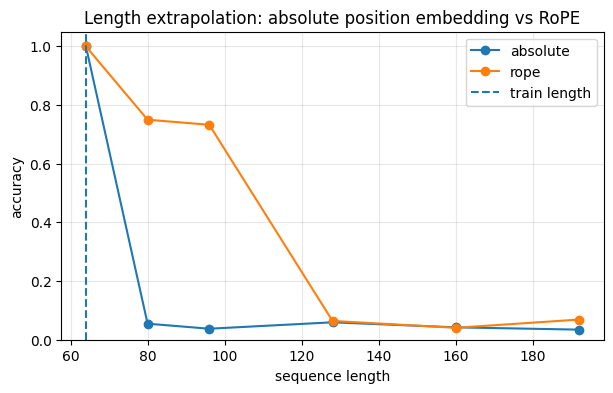

In [11]:
plt.figure(figsize=(7, 4))

for pos_type, group in result_df.groupby("pos_type"):
    group = group.sort_values("seq_len")
    plt.plot(group["seq_len"], group["accuracy"], marker="o", label=pos_type)

plt.axvline(TRAIN_LEN, linestyle="--", label="train length")
plt.xlabel("sequence length")
plt.ylabel("accuracy")
plt.title("Length extrapolation: absolute position embedding vs RoPE")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The experimental results show that, at the training length, both positional encoding methods can achieve nearly perfect accuracy. However, once the test sequence length exceeds the training length, the accuracy of direct absolute positional encoding quickly drops to a level close to random guessing. This is because position embeddings beyond the training length are not sufficiently updated during training, so the model cannot reliably interpret these new positions.

By contrast, RoPE still maintains significantly higher accuracy at test lengths 80 and 96, indicating that its rotary positional representation can support length extrapolation to some extent. RoPE does not learn an independent parameter for each absolute position. Instead, through position-dependent rotation angles, the dot product between query and key naturally contains relative positional information. Therefore, after exceeding the training length, RoPE can still compute meaningful positional relationships.

However, RoPE's accuracy also drops noticeably on longer sequences. This shows that RoPE is not equivalent to infinite-length generalization. As the sequence becomes longer, the retrieval space expands, more distracting tokens are introduced, and the rotational frequencies may also cause periodic aliasing over long distances. In this experiment, the advantage of RoPE is better medium-length extrapolation, not stable generalization to arbitrary lengths.


To further verify whether the model has truly learned correct relative-position retrieval on long sequences, the following experiment visualizes attention on a test sample of length 128. Specifically, the model uses only the final token as the query and computes attention over all key positions in the sequence. The vertical dashed line in the figure marks the theoretical target position, namely the position OFFSET steps before the final token. If the model has truly learned the task, its attention weights should form a clear peak near the dashed line. This visualization checks not only whether the final prediction is correct, but also whether the model obtains the answer by attending to the correct position, rather than relying on an incorrect position or accidental correlation. Therefore, it complements the previous accuracy curve: accuracy measures whether the result is correct, while the attention distribution helps determine whether the model internally forms a relative-position selection mechanism consistent with the task definition.


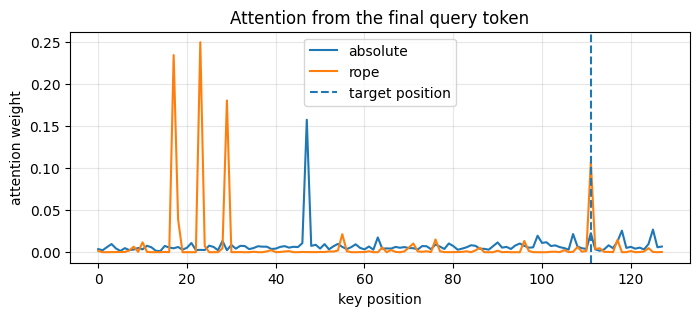

target value: 20
prediction: {'absolute': 18, 'rope': 19}


In [15]:
# visualize where the trained models attend on a long sequence.
# The correct target position is marked by the vertical dashed line.

L = 128
x, y = make_batch(batch_size=1, seq_len=L)

target_pos = L - 1 - OFFSET

plt.figure(figsize=(8, 3))

for pos_type, model in models.items():
    model.eval()
    with torch.no_grad():
        logits, att = model(x, return_attn=True)
    plt.plot(att[0].detach().cpu().numpy(), label=pos_type)

plt.axvline(target_pos, linestyle="--", label="target position")
plt.xlabel("key position")
plt.ylabel("attention weight")
plt.title("Attention from the final query token")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("target value:", int(y.item()))
print("prediction:", {k: int(m(x).argmax(dim=-1).item()) for k, m in models.items()})

From the figure above, under the condition OFFSET=16 and test length L=128, the theoretical target position is 111. The attention visualization shows that the attention peak of absolute position embedding clearly deviates from the target position, while RoPE forms a local peak near the target position, indicating that it still retains some relative-position retrieval ability. However, RoPE's maximum attention peak is not at the target position but at an earlier position, showing that the current minimal model has not formed a stable one-hop localization strategy. Therefore, this figure supports the claim that “RoPE has a stronger tendency toward length extrapolation than absolute positional encoding,” but it does not prove that the model has fully learned precise relative-position addressing.


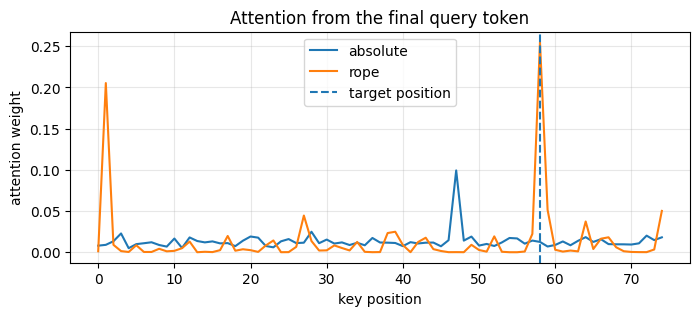

target value: 27
prediction: {'absolute': 16, 'rope': 27}


In [23]:
# visualize where the trained models attend on a long sequence.
# The correct target position is marked by the vertical dashed line.

L = 75
x, y = make_batch(batch_size=1, seq_len=L)

target_pos = L - 1 - OFFSET

plt.figure(figsize=(8, 3))

for pos_type, model in models.items():
    model.eval()
    with torch.no_grad():
        logits, att = model(x, return_attn=True)
    plt.plot(att[0].detach().cpu().numpy(), label=pos_type)

plt.axvline(target_pos, linestyle="--", label="target position")
plt.xlabel("key position")
plt.ylabel("attention weight")
plt.title("Attention from the final query token")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("target value:", int(y.item()))
print("prediction:", {k: int(m(x).argmax(dim=-1).item()) for k, m in models.items()})

In the test with L=75 and OFFSET=16, RoPE's attention peak is basically aligned with the theoretical target position, indicating that the model has learned to use relative positional information for retrieval. By contrast, the main attention peak of absolute position embedding deviates from the target position and produces a stronger response at another position.


### How to interpret this experiment

In general, you will see three kinds of phenomena.

First, within the training length range, for example $L = 64$, both models may learn the task well. This shows that the task itself is not difficult and that the model capacity is sufficient.

Second, after exceeding the training length, direct absolute position embedding usually degrades significantly. The reason is not that the attention formula cannot compute, but that after exceeding the training length, the position embedding of the query token's location has not been updated during training. Thus, when the query token is located at positions such as $79,95,127,159,191$, the input distribution has already become different from the training phase.

Third, RoPE usually degrades more slowly. This is because RoPE does not learn a separate position vector for each absolute position. Instead, it uses continuous rotation phases on Query and Key. That is, for new sequence lengths, positional relationships still have a clear computational form:

$$
q_m^\top R_{n-m} k_n.
$$

Therefore, RoPE can more easily express relative rules such as “the token $k$ positions before the current token.”

However, it must also be emphasized that RoPE's advantage is not that “it works at infinitely long lengths.” When the test length continues to increase, it may still degrade. Possible reasons include:

1. The model has not seen attention candidate sets that long during training.
2. The number of competing terms in softmax increases, and noisy keys can more easily steal attention.
3. The high-frequency dimensions of RoPE may exhibit phase wrapping.
4. The model parameters have only been optimized on a short-context distribution.

So the more accurate conclusion is:

> RoPE keeps positional relationships beyond the training length mathematically computable and makes it easier to reuse relative-position rules than direct absolute position embedding; however, it does not guarantee that the model automatically learns context retrieval at arbitrary lengths.

---


## Supplementary Experiment 2: The Strengths and Boundaries of Direct Relative Positional Encoding

Supplementary Experiment 1 compared absolute positional encoding with RoPE and showed that absolute positional encoding easily encounters the problem of untrained absolute positions during length extrapolation.

However, that comparison is still incomplete. Others could reasonably question the result: if absolute positional encoding is not used and direct relative positional encoding is used instead, then the model can also represent relations such as “the $k$-th token before the query.”

Therefore, Supplementary Experiment 2 is divided into two parts.

The first part is a **seen relative distance control**. We still use the fixed-offset retrieval task:

$$
y = x_{T-1-k}
$$

where $k$ remains the same during training and testing. This experiment shows that if the target relative distance $k$ has already appeared during training, then direct learned relative positional encoding can also work on longer sequences. In other words, RoPE's advantage on this task is not because “only RoPE knows relative positions,” but because absolute positional encoding itself suffers from the problem of untrained absolute positions.

The second part is an **unseen relative distance stress test**. During training, the model only sees relative distances no larger than the training length. During testing, it is required to handle relative distances that appear only in longer sequences. For direct learned relative positional encoding, each relative distance has an independent parameter:

$$
r_0, r_1, r_2, \cdots
$$

Although table entries for distances not seen during training can be created in advance, these entries are not effectively updated. Therefore, they merely “exist”; they have not been “learned.”

The difference with RoPE is that it does not learn a separate parameter for each relative distance. Instead, it computes relative positional relationships through a continuous rotation structure. Therefore, at least at the representational level, RoPE can naturally extend beyond the training length. However, this does not guarantee that RoPE can solve all long-distance tasks. It only means that RoPE does not have the hard boundary of “unlearned table entries for out-of-training distances” that a direct relative table has.


In [24]:
# ============================================================
# Supplementary Experiment 2
# Direct relative encoding: seen-distance control and unseen-distance stress test
# ============================================================

try:
    OFFSET
except NameError:
    OFFSET = 8


def make_fixed_offset_batch(batch_size, seq_len, offset=OFFSET):
    """
    Fixed-offset retrieval.

    Input:
        [v_0, v_1, ..., v_{T-2}, QUERY]

    Target:
        token at position T - 1 - offset

    The required relative distance is always `offset`.
    """
    assert seq_len >= offset + 2

    values = torch.randint(
        low=0,
        high=VALUE_VOCAB_SIZE,
        size=(batch_size, seq_len - 1),
        device=DEVICE,
    )

    query = torch.full(
        (batch_size, 1),
        QUERY_TOKEN_ID,
        dtype=torch.long,
        device=DEVICE,
    )

    x = torch.cat([values, query], dim=1)
    target_pos = seq_len - 1 - offset
    y = x[:, target_pos]

    return x, y


def make_first_token_batch_exp2(batch_size, seq_len):
    """
    First-token retrieval.

    Input:
        [v_0, v_1, ..., v_{T-2}, QUERY]

    Target:
        v_0

    The required relative distance is T - 1.
    Therefore, when T becomes larger than the training length,
    the task requires unseen relative distances.
    """
    assert seq_len >= 4

    values = torch.randint(
        low=0,
        high=VALUE_VOCAB_SIZE,
        size=(batch_size, seq_len - 1),
        device=DEVICE,
    )

    query = torch.full(
        (batch_size, 1),
        QUERY_TOKEN_ID,
        dtype=torch.long,
        device=DEVICE,
    )

    x = torch.cat([values, query], dim=1)
    y = values[:, 0]

    return x, y


def make_variable_length_first_token_train_batch(batch_size):
    """
    Training lengths are sampled from [16, TRAIN_LEN].

    Therefore, the model sees relative distances at most TRAIN_LEN - 1.
    """
    seq_len = int(torch.randint(
        low=16,
        high=TRAIN_LEN + 1,
        size=(1,),
    ).item())

    return make_first_token_batch_exp2(batch_size, seq_len)


class RelativeOrRoPERetriever(nn.Module):
    """
    A minimal last-query attention retriever.

    mode:
        "direct_relative":
            score(i, j) = q_i^T k_j + q_i^T r_{i-j}

        "rope":
            apply rotary position embedding to q and k
    """
    def __init__(
        self,
        mode,
        vocab_size=TOTAL_VOCAB_SIZE,
        value_vocab_size=VALUE_VOCAB_SIZE,
        d_model=D_MODEL,
        n_head=N_HEAD,
        max_len=MAX_TEST_LEN,
        dropout=DROPOUT,
    ):
        super().__init__()

        assert mode in {"direct_relative", "rope"}
        assert d_model % n_head == 0

        self.mode = mode
        self.max_len = max_len
        self.d_model = d_model
        self.n_head = n_head
        self.head_dim = d_model // n_head

        self.token_emb = nn.Embedding(vocab_size, d_model)

        if mode == "direct_relative":
            self.rel_key = nn.Embedding(2 * max_len - 1, d_model)
        else:
            self.rel_key = None

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

        self.out_proj = nn.Linear(d_model, d_model)
        self.ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, value_vocab_size)

    def forward(self, idx, return_attn=False):
        B, T = idx.shape

        if T > self.max_len:
            raise ValueError(f"sequence length {T} > max_len {self.max_len}")

        x = self.token_emb(idx)

        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        if self.mode == "rope":
            q = apply_rope(q)
            k = apply_rope(k)

        q_last = q[:, :, -1:, :]
        scores = q_last @ k.transpose(-2, -1)

        if self.mode == "direct_relative":
            query_pos = T - 1
            key_pos = torch.arange(T, device=idx.device)

            rel = query_pos - key_pos
            rel_index = rel + (self.max_len - 1)

            rel_vec = self.rel_key(rel_index)
            rel_vec = rel_vec.view(T, self.n_head, self.head_dim)
            rel_vec = rel_vec.permute(1, 0, 2)

            rel_scores = torch.einsum(
                "bhqd,htd->bhqt",
                q_last,
                rel_vec,
            )

            scores = scores + rel_scores

        scores = scores / math.sqrt(self.head_dim)

        att = F.softmax(scores, dim=-1)
        att = self.dropout(att)

        ctx = att @ v
        ctx = ctx.transpose(1, 2).contiguous().view(B, 1, self.d_model)
        ctx = ctx[:, 0, :]

        logits = self.head(self.ln(self.out_proj(ctx)))

        if return_attn:
            return logits, att.mean(dim=1).squeeze(1)

        return logits


def train_exp2_model(model, batch_fn, train_steps=TRAIN_STEPS, label=None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    rows = []
    model.train()

    for step in range(1, train_steps + 1):
        x, y = batch_fn(BATCH_SIZE)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step == 1 or step % 100 == 0:
            with torch.no_grad():
                acc = (logits.argmax(dim=-1) == y).float().mean().item()

            rows.append({
                "model": label or model.mode,
                "step": step,
                "loss": loss.item(),
                "train_batch_acc": acc,
            })

            print(
                f"{label or model.mode:>28s} | "
                f"step {step:4d} | "
                f"loss {loss.item():.4f} | "
                f"train acc {acc:.3f}"
            )

    return pd.DataFrame(rows)


@torch.no_grad()
def evaluate_exp2_model(model, batch_fn, lengths, label=None):
    model.eval()

    rows = []

    for L in lengths:
        correct = 0
        total = 0

        for _ in range(EVAL_BATCHES):
            x, y = batch_fn(BATCH_SIZE, L)
            logits = model(x)
            pred = logits.argmax(dim=-1)

            correct += (pred == y).sum().item()
            total += y.numel()

        rows.append({
            "model": label or model.mode,
            "seq_len": L,
            "is_extrapolation": L > TRAIN_LEN,
            "accuracy": correct / total,
        })

    return pd.DataFrame(rows)

### Experiment 2A

This experiment compares whether direct relative encoding and RoPE can handle longer test sequences when the “relative distance has already been seen.” During both training and testing, the model needs to retrieve the target value at distance OFFSET from the final token, so the target relative distance is always the same seen distance. This setting is favorable to direct relative encoding because it only needs to use the relative-distance parameter learned during training. It is also a test for RoPE, because although RoPE does not learn an independent parameter for each relative distance, it still needs to produce the correct rotation relationship at longer absolute positions.

Therefore, this experiment aims to distinguish the differences between two “relative-position mechanisms”: direct relative encoding may perform well on seen relative distances, but its ability depends on the distance table observed during training; RoPE computes relative relationships through a continuous rotation formula and can generate the corresponding relative geometry at new absolute positions even when the sequence becomes longer. If both perform well in Experiment 2A, it means that when the target relative distance has been seen, direct relative encoding does not fail merely because the test sequence is longer. It also shows that RoPE can maintain retrieval of the same offset at longer positions. This experiment provides a control group for the later test of “unseen relative distances.”


Experiment 2A training: direct_relative_seen_offset
 direct_relative_seen_offset | step    1 | loss 3.6458 | train acc 0.047
 direct_relative_seen_offset | step  100 | loss 0.5754 | train acc 1.000
 direct_relative_seen_offset | step  200 | loss 0.0695 | train acc 1.000
 direct_relative_seen_offset | step  300 | loss 0.0297 | train acc 1.000
 direct_relative_seen_offset | step  400 | loss 0.0176 | train acc 1.000
 direct_relative_seen_offset | step  500 | loss 0.0120 | train acc 1.000
 direct_relative_seen_offset | step  600 | loss 0.0083 | train acc 1.000
 direct_relative_seen_offset | step  700 | loss 0.0062 | train acc 1.000
 direct_relative_seen_offset | step  800 | loss 0.0049 | train acc 1.000
 direct_relative_seen_offset | step  900 | loss 0.0041 | train acc 1.000
 direct_relative_seen_offset | step 1000 | loss 0.0032 | train acc 1.000
Experiment 2A training: rope_seen_offset
            rope_seen_offset | step    1 | loss 3.4667 | train acc 0.047
            rope_seen_offset | 

,model,seq_len,is_extrapolation,accuracy
0,direct_relative_seen_offset,64,False,1.000000
1,direct_relative_seen_offset,80,True,1.000000
2,direct_relative_seen_offset,96,True,1.000000
3,direct_relative_seen_offset,128,True,1.000000
4,direct_relative_seen_offset,160,True,1.000000
5,direct_relative_seen_offset,192,True,1.000000
6,rope_seen_offset,64,False,1.000000
7,rope_seen_offset,80,True,0.750000
8,rope_seen_offset,96,True,0.770312
9,rope_seen_offset,128,True,0.101562


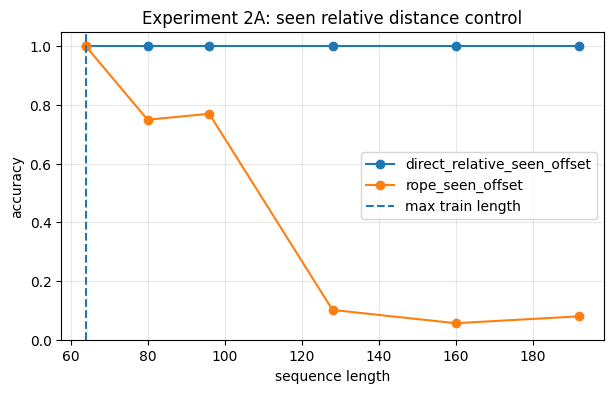

In [27]:
# ============================================================
# Experiment 2A
# Seen relative distance control
# ============================================================
#
# Here the required relative distance is always OFFSET.
# Since OFFSET is already seen during training, direct relative encoding
# should not fail merely because the test sequence is longer.

set_seed(SEED)

exp2a_models = {
    "direct_relative_seen_offset": RelativeOrRoPERetriever("direct_relative").to(DEVICE),
    "rope_seen_offset": RelativeOrRoPERetriever("rope").to(DEVICE),
}

exp2a_histories = []
exp2a_results = []

for name, model in exp2a_models.items():
    print("=" * 80)
    print("Experiment 2A training:", name)

    hist = train_exp2_model(
        model,
        batch_fn=lambda batch_size: make_fixed_offset_batch(
            batch_size,
            seq_len=TRAIN_LEN,
            offset=OFFSET,
        ),
        label=name,
    )

    result = evaluate_exp2_model(
        model,
        batch_fn=lambda batch_size, seq_len: make_fixed_offset_batch(
            batch_size,
            seq_len=seq_len,
            offset=OFFSET,
        ),
        lengths=TEST_LENGTHS,
        label=name,
    )

    exp2a_histories.append(hist)
    exp2a_results.append(result)

exp2a_history_df = pd.concat(exp2a_histories, ignore_index=True)
exp2a_result_df = pd.concat(exp2a_results, ignore_index=True)

display(exp2a_result_df)


plt.figure(figsize=(7, 4))

for model_name, group in exp2a_result_df.groupby("model"):
    group = group.sort_values("seq_len")
    plt.plot(
        group["seq_len"],
        group["accuracy"],
        marker="o",
        label=model_name,
    )

plt.axvline(TRAIN_LEN, linestyle="--", label="max train length")
plt.xlabel("sequence length")
plt.ylabel("accuracy")
plt.title("Experiment 2A: seen relative distance control")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The results of Experiment 2A show that when training and testing both use the same seen relative distance OFFSET, direct relative encoding maintains nearly 100% accuracy across all test lengths. This indicates that direct relative encoding does not naturally fail simply because the absolute sequence length becomes longer. As long as the required retrieval distance has appeared during training, it can stably reuse the corresponding relative-distance parameter.

By contrast, although RoPE performs normally within the training length, its accuracy drops clearly once the test sequence exceeds the training length and approaches random level on longer sequences. This shows that although RoPE's positional representation can be extended to arbitrary lengths mathematically, the query-key matching relation actually learned by the model does not automatically generalize to farther absolute positions. In other words, RoPE provides a continuous rotary positional representation, not a guarantee of stable extrapolation at arbitrary lengths.

Therefore, the key conclusion of Experiment 2A is: when the target relative distance is the seen OFFSET, direct relative encoding is actually more stable than RoPE. This result shows that the length extrapolation problem cannot be simply understood as “relative positional encoding is always better than a directly learned relative-distance table.” For seen relative distances, direct relative positional encoding can precisely reuse the parameters learned during training; RoPE may still fail due to distribution drift of rotations at longer absolute positions, frequency aliasing, or insufficient training range.


### Experiment 2B

This is an unseen relative distance stress test. Unlike Experiment 2A, which uses a fixed OFFSET, this experiment requires the final query token to retrieve the first token in the sequence. Therefore, the required relative distance equals seq_len - 1. During training, the maximum sequence length is TRAIN_LEN, so the model has seen at most relative distances up to TRAIN_LEN - 1. During testing, the sequences are longer, and the required relative distances exceed the training range.

This setting is specifically designed to examine the extrapolation ability of direct relative encoding and RoPE on unseen relative distances. For direct relative encoding, embedding table rows corresponding to relative distances beyond the training range are not updated and remain close to random initialization. Therefore, the model is expected to fail on long sequences. By contrast, RoPE does not learn a separate parameter for each relative distance. It continuously defines relative relationships between arbitrary positions through rotation functions, so in theory it has better extrapolation potential on unseen relative distances. This experiment contrasts with Experiment 2A: 2A tests “long-sequence generalization under seen relative distances,” while 2B tests “true distance extrapolation under unseen relative distances.”


Experiment 2B training: direct_relative_unseen_distance
direct_relative_unseen_distance | step    1 | loss 3.5840 | train acc 0.016
direct_relative_unseen_distance | step  100 | loss 3.2827 | train acc 0.156
direct_relative_unseen_distance | step  200 | loss 3.2074 | train acc 0.156
direct_relative_unseen_distance | step  300 | loss 3.6508 | train acc 0.031
direct_relative_unseen_distance | step  400 | loss 3.0323 | train acc 0.141
direct_relative_unseen_distance | step  500 | loss 2.2472 | train acc 0.344
direct_relative_unseen_distance | step  600 | loss 2.4368 | train acc 0.422
direct_relative_unseen_distance | step  700 | loss 2.1144 | train acc 0.359
direct_relative_unseen_distance | step  800 | loss 2.5189 | train acc 0.188
direct_relative_unseen_distance | step  900 | loss 2.3119 | train acc 0.344
direct_relative_unseen_distance | step 1000 | loss 2.1009 | train acc 0.375
Experiment 2B training: rope_unseen_distance
        rope_unseen_distance | step    1 | loss 3.5232 | train 

,model,seq_len,is_extrapolation,accuracy,required_relative_distance
0,direct_relative_unseen_distance,64,False,0.045312,63
1,direct_relative_unseen_distance,80,True,0.040625,79
2,direct_relative_unseen_distance,96,True,0.029687,95
3,direct_relative_unseen_distance,128,True,0.037500,127
4,direct_relative_unseen_distance,160,True,0.037500,159
5,direct_relative_unseen_distance,192,True,0.034375,191
6,rope_unseen_distance,64,False,0.664062,63
7,rope_unseen_distance,80,True,0.073438,79
8,rope_unseen_distance,96,True,0.040625,95
9,rope_unseen_distance,128,True,0.035937,127


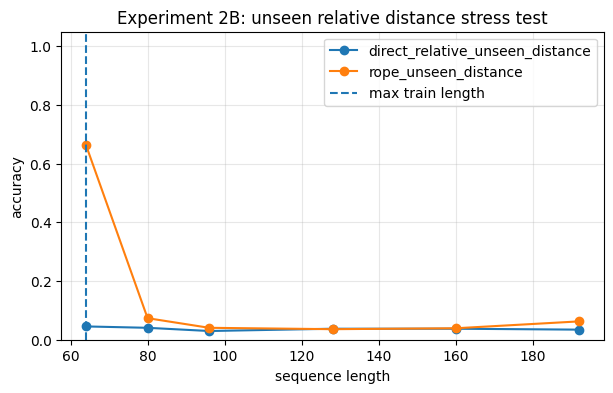

In [28]:
# ============================================================
# Experiment 2B
# Unseen relative distance stress test
# ============================================================
#
# Here the model is trained on first-token retrieval with variable
# sequence lengths up to TRAIN_LEN.
#
# During testing, longer sequences require relative distances larger
# than TRAIN_LEN - 1.
#
# For direct relative encoding, those table rows are not trained.

set_seed(SEED)

direct_unseen_model = RelativeOrRoPERetriever("direct_relative").to(DEVICE)
direct_unseen_rel_key_init = direct_unseen_model.rel_key.weight.detach().clone()

rope_unseen_model = RelativeOrRoPERetriever("rope").to(DEVICE)

exp2b_models = {
    "direct_relative_unseen_distance": direct_unseen_model,
    "rope_unseen_distance": rope_unseen_model,
}

exp2b_histories = []
exp2b_results = []

for name, model in exp2b_models.items():
    print("=" * 80)
    print("Experiment 2B training:", name)

    hist = train_exp2_model(
        model,
        batch_fn=make_variable_length_first_token_train_batch,
        label=name,
    )

    result = evaluate_exp2_model(
        model,
        batch_fn=make_first_token_batch_exp2,
        lengths=TEST_LENGTHS,
        label=name,
    )

    result["required_relative_distance"] = result["seq_len"] - 1

    exp2b_histories.append(hist)
    exp2b_results.append(result)

exp2b_history_df = pd.concat(exp2b_histories, ignore_index=True)
exp2b_result_df = pd.concat(exp2b_results, ignore_index=True)

display(exp2b_result_df)


plt.figure(figsize=(7, 4))

for model_name, group in exp2b_result_df.groupby("model"):
    group = group.sort_values("seq_len")
    plt.plot(
        group["seq_len"],
        group["accuracy"],
        marker="o",
        label=model_name,
    )

plt.axvline(TRAIN_LEN, linestyle="--", label="max train length")
plt.xlabel("sequence length")
plt.ylabel("accuracy")
plt.title("Experiment 2B: unseen relative distance stress test")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The results show that direct relative encoding is close to random level across all test lengths, indicating that it has not learned to generalize to unseen relative distances. This is expected, because the embedding table rows corresponding to relative distances beyond the training length are not updated during training, and the model cannot reliably use these untrained relative-distance parameters.

RoPE still has some accuracy at the test point closest to the training length, but it also quickly drops to a level close to random guessing as the sequence length increases. This indicates that although RoPE can mathematically compute rotary representations for arbitrary positions, the query-key matching relation actually learned by the model does not automatically generalize to relative distances far beyond the training range. In particular, this experiment requires retrieval of the first token in the sequence, so the relative distance grows linearly with sequence length. This is more difficult than fixed-OFFSET retrieval, because the model must not only deal with attention competition in longer sequences, but also face large-distance positional relationships that never appeared during training.

Therefore, the conclusion of Experiment 2B is: direct relative encoding can hardly extrapolate to unseen relative distances; although RoPE has a continuous positional representation, under the current model size, training length, and task setting, it also does not guarantee stable long-distance extrapolation. This result shows that RoPE's advantage is not that “it can generalize to any distance,” but that, compared with lookup-table relative positional encoding, it provides a defined and computable extrapolation mechanism. Whether the model can ultimately extrapolate still depends on the training distribution, model capacity, and task difficulty.


### Which relative-distance embedding parameters are actually updated?

The following code directly checks which rows in the relative-distance embedding table are actually updated during training.


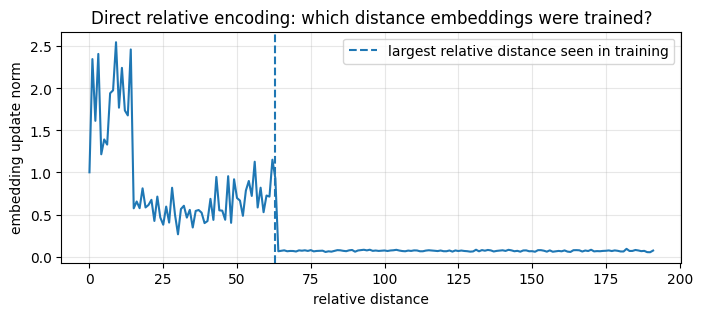

In [29]:
# ============================================================
# Diagnostic plot
# Which relative-distance embeddings were actually updated?
# ============================================================

with torch.no_grad():
    direct_unseen_rel_key_after = direct_unseen_model.rel_key.weight.detach().clone()

delta = torch.norm(
    direct_unseen_rel_key_after - direct_unseen_rel_key_init,
    dim=-1,
)

distances = torch.arange(0, MAX_TEST_LEN, device=DEVICE)
indices = distances + (MAX_TEST_LEN - 1)
distance_delta = delta[indices].detach().cpu().numpy()

plt.figure(figsize=(8, 3))
plt.plot(distances.detach().cpu().numpy(), distance_delta)

plt.axvline(
    TRAIN_LEN - 1,
    linestyle="--",
    label="largest relative distance seen in training",
)

plt.xlabel("relative distance")
plt.ylabel("embedding update norm")
plt.title("Direct relative encoding: which distance embeddings were trained?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This diagnostic plot shows the magnitude of parameter changes before and after training for different relative-distance embeddings in direct relative encoding. The horizontal axis is relative distance, and the vertical axis is the update norm of the corresponding embedding row. The dashed line indicates the largest relative distance that can appear during training, namely TRAIN_LEN - 1.

The result shows that on the left side of the dashed line, that is, within the range of relative distances that may have appeared during training, the embedding update norm is clearly larger. This indicates that the parameters corresponding to these distances were indeed updated during training. The update magnitude is especially larger at shorter distances, suggesting that these distances appeared more frequently in training samples or contributed more directly to the task.

On the right side of the dashed line, the update norm drops almost to 0 and remains flat. This indicates that relative-distance embeddings beyond TRAIN_LEN - 1 were basically not updated during training and still remain close to random initialization.

Therefore, this figure directly explains why direct relative encoding collapses in Experiment 2B: long test sequences require the model to use relative distances larger than those seen during training, such as seq_len - 1, but the embedding table rows corresponding to these distances have never been trained. Direct relative encoding does not generate positional relationships for arbitrary distances through a continuous function. Instead, it relies on a discrete relative-distance parameter table. Once the test process accesses untrained table entries, the model cannot reliably perform relative-position retrieval.


### Visualizing attention behavior inside the sequence

The following visualization checks the internal attention behavior of the two models in Experiment 2B on the longest test sequence.

Because this experiment is first-token retrieval, the correct target position is always key position 0, while the query is located at the end of the sequence. Therefore, if the model can successfully extrapolate to a large unseen relative distance, its attention should form a clear peak at position 0. By plotting the attention weights from the final query token to all key positions, we can observe whether direct relative encoding and RoPE have truly learned to locate the first token in a long sequence. The printed prediction at the end is used to compare whether the attention behavior is consistent with the final classification result.


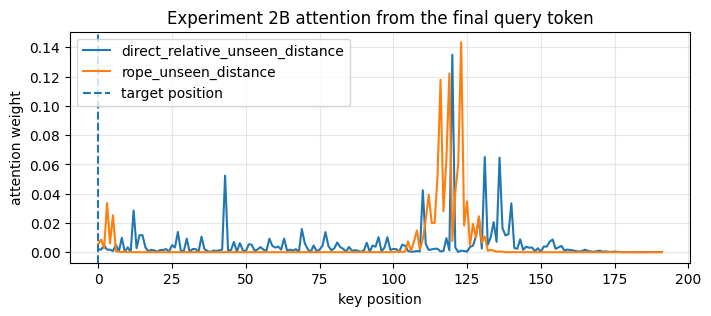

Target value: 2
 direct_relative_unseen_distance prediction: 29
            rope_unseen_distance prediction: 18


In [31]:
# ============================================================
# Attention visualization for Experiment 2B
# ============================================================

L = max(TEST_LENGTHS)
x, y = make_first_token_batch_exp2(batch_size=1, seq_len=L)

plt.figure(figsize=(8, 3))

for name, model in exp2b_models.items():
    model.eval()

    with torch.no_grad():
        logits, att = model(x, return_attn=True)

    plt.plot(
        att[0].detach().cpu().numpy(),
        label=name,
    )

plt.axvline(0, linestyle="--", label="target position")
plt.xlabel("key position")
plt.ylabel("attention weight")
plt.title("Experiment 2B attention from the final query token")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("Target value:", int(y.item()))

for name, model in exp2b_models.items():
    with torch.no_grad():
        pred = model(x).argmax(dim=-1).item()

    print(f"{name:>32s} prediction:", int(pred))

The attention visualization further confirms the failure mechanism in Experiment 2B. In this task, the final query token should retrieve the first token in the sequence, so the correct key position is 0. However, the main attention peaks of both direct relative encoding and RoPE do not fall near position 0, but instead concentrate around the middle-to-late part of the sequence. This shows that neither model has learned correct long-distance localization under unseen large relative distances. The failure of direct relative encoding comes from untrained relative-distance table entries. RoPE can mathematically define rotation relationships at arbitrary distances, but the current model has not generalized the query-key matching rule learned during training to such long relative distances.


## Conclusion of Supplementary Experiment 2

The purpose of Supplementary Experiment 2 is not to prove that RoPE will always succeed on all length extrapolation tasks. Instead, it further distinguishes direct learned relative positional encoding and RoPE in terms of “relative distances outside the training range.”

From the diagnostic plot of embedding update norms, we can see that in direct relative encoding, position vectors within the range of relative distances that appeared during training undergo clear updates. Once the distance exceeds the maximum relative distance in training, the update magnitude quickly approaches 0. This shows that although direct relative encoding can create table entries for longer distances in advance, the vectors corresponding to these out-of-training distances are not effectively learned.

Therefore, the problem with direct relative encoding is not that it cannot express relative positions. The problem is that it learns every relative distance as an independent parameter:

$$
r_0, r_1, r_2, \cdots
$$

When testing requires a relative distance that did not appear during training, the corresponding parameter merely “exists,” but has not been “learned.” This lookup-table structure itself lacks a natural mechanism for distance extrapolation.

The second attention figure also shows that this first-token retrieval task is more difficult than fixed-offset retrieval. The target position is the beginning of the sequence, namely key position 0. However, the attention distribution of direct relative encoding is rather scattered, and RoPE's attention peak also does not stably fall on the target position. This indicates that the model has not truly learned the abstract boundary rule: “attend to the leftmost token regardless of sequence length.”

Therefore, RoPE's advantage should not be overinterpreted as “automatically solving all length extrapolation tasks.” A more accurate statement is that RoPE does not store an independent parameter for each relative distance. Instead, it generates relative positional relationships through a continuous rotation structure. Therefore, when the sequence length exceeds the training length, RoPE's positional relationships still have a structured mathematical definition and do not encounter the problem that out-of-training table entries are almost unupdated, as in a direct relative table.

In summary, Supplementary Experiment 2 supports the following conclusion: direct learned relative positional encoding can handle relative distances seen during training, but when testing requires relative distances outside the training range, it exposes the extrapolation boundary of lookup-table parameterization. RoPE alleviates the extensibility problem of the positional representation itself, but it does not guarantee that the model will necessarily learn all task rules requiring length generalization.
